## LLamaFactory on Amazon SageMaker Training Job

本示例通过 LLamaFactory 及 Amazon SageMaker Training Job 的方式训练模型。
- Model: Qwen2.5-0.5B
- Method: SFT

Notebook 环境选择 python 3 即可。

In [4]:
%cd ~/SageMaker/llm_model_hub/backend

/home/ec2-user/SageMaker/llm_model_hub/backend


### 获取 SageMaker Notebook 实例基本信息

In [5]:
import sagemaker
import boto3, os
from sagemaker import get_execution_role

sess = sagemaker.Session()
sagemaker_session=sess
role = get_execution_role()
default_bucket = sess.default_bucket()
region = sess.boto_session.region_name

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [6]:
# Create a Boto3 STS client
sts_client = boto3.client('sts')

# Get the caller identity
response = sts_client.get_caller_identity()

# Extract the account ID from the response
account_id = response['Account']
account_id

'022346938362'

### 编译用来训练的容器镜像

**Note: 此步骤耗时较久，约 20 分钟。**

在 Terminal 中执行如下命令：

```bash
cd ~/SageMaker/llm_model_hub/backend/docker
bash build_and_push.sh
```

如下图所示：

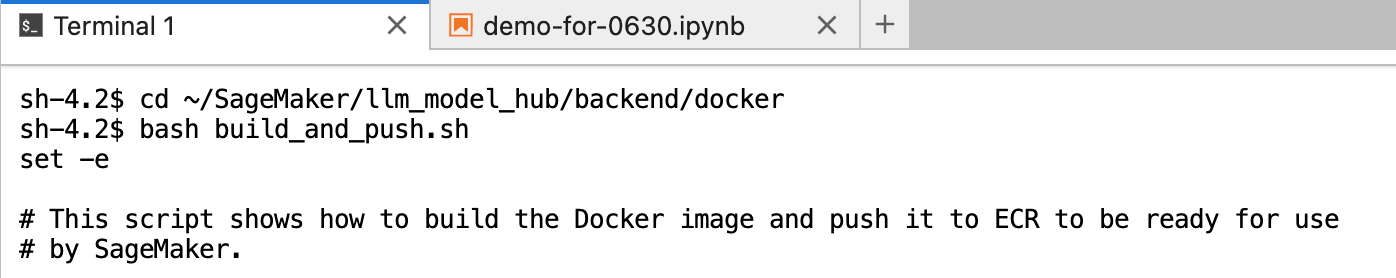

### 相关环境变量配置

In [71]:
WANDB_BASE_URL=''  # optional
WANDB_API_KEY=''   # optional
SWANLAB_API_KEY='' # optional
HUGGING_FACE_HUB_TOKEN='' # required

# 用来训练的 docker uri
image_uri = f"{account_id}.dkr.ecr.us-east-1.amazonaws.com/sagemaker/llamafactory:0.9.3"
use_spot=False

### 辅助函数

- create_training_estimator: 提供 SageMaker 作业的配置信息，包括：环境变量、容器信息、实例数量等。
- prepare_dataset_info: 准备训练数据集文件信息
- save_json_to_s3: 将 json 保存到 S3 文件

In [77]:
import json

from sagemaker.pytorch import PyTorch
from sagemaker.estimator import Estimator

def create_training_estimator(
    job_id: str,
    model_id:str,
    dataset_info_path:str,
    sg_config:str,
    use_spot:bool,
    max_spot_wait:int,
    max_job_run_hour:int,
    sg_lora_merge_config:str,
    instance_type:str ,
    instance_num:int,
    s3_checkpoint:str,
    s3_model_path:str,
    merge_lora:str = '1',
    training_input_path:str=None):

    base_model_name = model_id.split('/')[-1]
    base_job_name = base_model_name.replace('.','-')

    output_s3_path = f's3://{default_bucket}/{base_job_name}/{job_id}/'
    environment = {
        'NODE_NUMBER': str(instance_num),
        "s3_data_paths": f"{training_input_path}",
        "dataset_info_path": dataset_info_path,
        "s3_checkpoint": s3_checkpoint,
        "s3_model_path":s3_model_path,
        "USE_EFA": "1",  # "0"
        "HUGGING_FACE_HUB_TOKEN": HUGGING_FACE_HUB_TOKEN,
        "merge_lora": merge_lora,
        "merge_args_path": sg_lora_merge_config,
        "train_args_path": sg_config,
        'OUTPUT_MODEL_S3_PATH': output_s3_path, # destination 
        "REGION": region,
        "USE_MODELSCOPE_HUB": '0'
    }
    if WANDB_BASE_URL:
        environment["WANDB_BASE_URL"] = WANDB_BASE_URL
    if WANDB_API_KEY:
        environment["WANDB_API_KEY"] = WANDB_API_KEY
    else:
        environment["WANDB_DISABLED"] = "true"
    # entry_point = 'entry_single_lora.py' if instance_num == 1 else 'entry-multi-nodes.py'
    output_s3_path = output_s3_path
    estimator = Estimator(image_uri=image_uri,
                        role=role,
                        use_spot_instances=use_spot,
                        sagemaker_session=sagemaker_session,
                        base_job_name=base_job_name,
                        environment=environment,
                        instance_count=instance_num,
                        instance_type=instance_type,
                        max_wait= 3600*max_spot_wait if use_spot else None,
                        max_run=3600*max_job_run_hour,
                        enable_remote_debug=True,
                        keep_alive_period_in_seconds=3600,
                        # checkpoint_local_path='/tmp/finetuned_model',
                        # checkpoint_s3_uri=output_s3_path[:-1]
                        )
    return estimator


def save_json_to_s3(s3_path, data):
    s3_resource = sess.boto_session.resource('s3')
    bucket_name, key = s3_path.replace('s3://', '').split('/',1)
    s3_resource.Object(bucket_name,key).put(Body=json.dumps(data))
    return s3_path


def prepare_dataset_info(data_info):
    file_name = './docker/LLaMA-Factory/data/dataset_info.json'
    try:
        with open(file_name, 'r') as f:
            datainfo = json.load(f)
        for key in list(data_info.keys()):
            datainfo[key] = data_info[key]
        # with open(file_name, 'w') as f:
        #     json.dump(datainfo, f)
        return datainfo
        # logger.info('Successfully saved dataset_info.json')
    except Exception as e:
        print(f'Error in prepare_dataset_info: {str(e)}')
        return {}

#### 示例训练作业参数

In [32]:
request = {
  "job_name": "demo-qwen2.5-0.5b",
  "job_type": "sft",
  "job_payload": {
    "model_name": "Qwen/Qwen2.5-0.5B-Instruct",
    "dataset": [
      "identity"
    ],
    "prompt_template": "Qwen2.5-0.5B-Instruct",
    "stage": "sft",
    "quantization_bit": "none",
    "finetuning_method": "lora",
    "learning_rate": "5e-5",
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "num_train_epochs": 2,
    "training_precision": "bf16",
    "max_samples": 50000,
    "cutoff_len": 1024,
    "val_size": 0.05,
    "logging_steps": 10,
    "warmup_steps": 10,
    "save_steps": 500,
    "optimizer": "adamw_torch",
    "lora_rank": 8,
    "lora_alpha": 16,
    "instance_type": "ml.g5.2xlarge",
    "instance_num": 1,
    "s3_data_path": "s3://sagemaker-us-east-1-022346938362/qwen2-train-dataset/",
    "dataset_info": "{\n    \"demo\":\n    {\n        \"file_name\":\"alpaca_zh_demo.json\"\n    }\n}",
    "dataset_info2": "{\n    \"train_file\":\"your_dataset_name.parquet\",\n    \"val_file\":\"your_dataset_name.parquet\"\n}",
    "booster_option": "auto",
    "deepspeed": "none",
    "s3_checkpoint": "",
    "s3_model_path": "",
    "use_spot": False,
    "max_spot_wait": 72,
    "max_job_run_hour": 72,
    "lora_target_modules": "all",
    "pref_beta": 0.1,
    "pref_loss": "sigmoid",
    "pref_ftx": 0,
    "max_steps": 10000,
    "max_prompt_length": 2048,
    "max_response_length": 2048,
    "save_freq": 50,
    "val_freq": 50,
    "limit_images": 0,
    "rollout_tensor_parallel_size": 1,
    "reward_function": "math:compute_score",
    "customize_reward_function": "",
    "format_prompt": None,
    "format_prompt_type": "math",
    "total_epochs": 10
  }
}

#### 构造训练数据

In [78]:
dataset_info = json.loads(request['job_payload']['dataset_info'])
dataset_info = prepare_dataset_info(dataset_info)

dataset_info_path = f's3://{default_bucket}/llm_modelhub/dataset_info/dataset_info_demo.json'

save_json_to_s3(dataset_info_path, dataset_info)


's3://sagemaker-us-east-1-022346938362/llm_modelhub/dataset_info/dataset_info_demo.json'

#### 构造 LlamaFactory 作业信息

In [45]:
LORA_BASE = './docker/LLaMA-Factory/examples/train_lora/llama3_lora_sft.yaml'
import yaml
from datetime import datetime
import shortuuid

def create_training_args(stage, job_payload, data_keys, model_id, base_config):

    with open(base_config) as f:
        doc = yaml.safe_load(f)

    doc.pop('resume_from_checkpoint',None)
    doc['output_dir'] ='/tmp/finetuned_model'
    doc['per_device_train_batch_size'] =int(job_payload['per_device_train_batch_size'])
    doc['gradient_accumulation_steps'] =int(job_payload['gradient_accumulation_steps'])
    doc['template'] = "qwen"

    #如果使用lora微调
    if job_payload['finetuning_method'] == 'lora':
        doc['finetuning_type'] = 'lora'
        doc['lora_target'] = job_payload.get('lora_target_modules','all')
        doc['lora_rank'] = int(job_payload['lora_rank'])
        doc['lora_alpha'] = int(job_payload['lora_alpha'])

        ## temp test `ddp_find_unused_parameters` needs to be set as False for LoRA in DDP training.
        doc['ddp_find_unused_parameters'] = False
    else:
        doc['finetuning_type'] = 'full'

    #如果是dpo或者kto, 暂时固定值
    if stage == 'dpo':
        doc['pref_beta'] = float(job_payload.get("pref_beta",0.1))
        doc['pref_loss'] = job_payload.get("pref_loss",'sigmoid')
        doc['pref_ftx'] = float(job_payload.get("pref_ftx",0))
        doc['stage'] = 'dpo'
    elif stage == 'kto':
        doc['pref_beta'] = float(job_payload.get("pref_beta",0.1))
        doc['pref_loss'] = float(job_payload.get("pref_loss",'sigmoid'))
        doc['pref_ftx'] = float(job_payload.get("pref_ftx",0))
        doc['stage'] = 'kto'
    elif stage == 'pt':
        doc['stage'] = 'pt'
        doc['template'] = 'default'

    doc['model_name_or_path'] = model_id    
    doc['learning_rate']=  float(job_payload['learning_rate'])
    doc['cutoff_len'] = int(job_payload['cutoff_len'])
    doc['num_train_epochs'] = float(job_payload['num_train_epochs'])
    doc['warmup_steps'] = int(job_payload['warmup_steps'])
    doc['logging_steps'] = int(job_payload['logging_steps'])
    doc['save_steps'] = int(job_payload['save_steps'])

    if val_size:=float(job_payload['val_size']):
        doc['val_size'] = val_size
        doc['eval_steps'] = int(job_payload['logging_steps'])
        doc['eval_strategy'] = 'steps'
        doc['per_device_eval_batch_size'] = 2
    else:
        if 'val_size' in doc:
            doc.pop('val_size', None)
            doc.pop('eval_strategy', None)
            doc.pop('per_device_eval_batch_size', None)
            doc.pop('eval_steps', None)

    if job_payload['booster_option'] == 'fa2':
        doc['flash_attn'] = 'fa2'
    elif job_payload['booster_option']  == 'use_unsloth':
        doc['flash_attn'] = 'auto'
        doc['use_unsloth'] = True
    elif job_payload['booster_option']  == 'liger_kernel':
        doc['flash_attn'] = 'auto'
        doc['enable_liger_kernel'] = True
    else:
        doc['flash_attn'] = 'auto'

    #WANDB
    if WANDB_API_KEY:
        doc['report_to'] = "wandb"
        timestp = to_datetime_string(time.time()).replace(' ', '_')
        doc['run_name'] = f"modelhub_run_{timestp}"
    else:
        doc['report_to'] = "none"

    if SWANLAB_API_KEY:
        doc['use_swanlab'] = True
        timestp = to_datetime_string(time.time()).replace(' ', '_')
        doc['swanlab_run_name'] = f"sagemaker_modelhub_run_{timestp}"
        doc['swanlab_project'] = f"sagemaker_modelhub"
        doc['swanlab_api_key'] = SWANLAB_API_KEY

    #训练精度
    if job_payload['training_precision'] == 'bf16':
        doc.pop('fp16', None)
        doc.pop('pure_bf16', None)
        doc['bf16'] = True
    elif job_payload['training_precision'] == 'fp16':
        doc.pop('bf16', None)
        doc.pop('pure_bf16', None)
        doc['fp16'] = True
    elif job_payload['training_precision'] == 'pure_bf16':
        doc.pop('bf16', None)
        doc.pop('bf16', None)
        doc['pure_bf16'] = True
    elif job_payload['training_precision'] == 'fp32':
        doc.pop('bf16', None)
        doc.pop('bf16', None)
        doc.pop('pure_bf16', None)

    doc['optim'] = job_payload['optimizer']

    #using bitandbytes to quantize 
    if job_payload['quantization_bit'] in ['4','8']:
        doc['quantization_bit'] = int(job_payload['quantization_bit'])

    #实验时间，只选取前max_samples条数据做训练
    doc['max_samples'] = int(job_payload['max_samples'])
    #数据集
    doc['dataset'] = ','.join(data_keys)
    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    uuid = shortuuid.uuid()
    train_args_path = f's3://{default_bucket}/llm_modelhub/args/train_args_{timestamp}_{uuid}.json'
    save_json_to_s3(train_args_path, doc)
    print(f'training args:\n{doc}')
    print(f'save training args:\n{train_args_path}')

    doc_merge = {}
    doc_merge['model_name_or_path'] = model_id
    doc_merge['adapter_name_or_path'] ='/tmp/finetuned_model'
    doc_merge['export_dir'] ='/tmp/finetuned_model_merged'
    doc_merge['template'] =  "qwen"
    doc_merge['export_size'] = 5
    doc_merge['export_device'] = 'auto'
    doc_merge['export_legacy_format'] = False


    merge_args_path = f's3://{default_bucket}/llm_modelhub/args/merge_args_{timestamp}_{uuid}.json'
    save_json_to_s3(merge_args_path, doc_merge)
    print(f'merge args:\n{doc}')
    print(f'save merge args:\n{merge_args_path}')

    return train_args_path, merge_args_path

sg_config, sg_lora_merge_config = create_training_args('sft', request['job_payload'], ['demo'], 'Qwen/Qwen2.5-0.5B-Instruct', LORA_BASE)

training args:
{'model_name_or_path': 'Qwen/Qwen2.5-0.5B-Instruct', 'trust_remote_code': True, 'stage': 'sft', 'do_train': True, 'finetuning_type': 'lora', 'lora_rank': 8, 'lora_target': 'all', 'dataset': 'demo', 'template': 'qwen', 'cutoff_len': 1024, 'max_samples': 50000, 'overwrite_cache': True, 'preprocessing_num_workers': 16, 'dataloader_num_workers': 4, 'output_dir': '/tmp/finetuned_model', 'logging_steps': 10, 'save_steps': 500, 'plot_loss': True, 'overwrite_output_dir': True, 'save_only_model': False, 'report_to': 'none', 'per_device_train_batch_size': 2, 'gradient_accumulation_steps': 4, 'learning_rate': 5e-05, 'num_train_epochs': 2.0, 'lr_scheduler_type': 'cosine', 'warmup_ratio': 0.1, 'bf16': True, 'ddp_timeout': 180000000, 'lora_alpha': 16, 'ddp_find_unused_parameters': False, 'warmup_steps': 10, 'val_size': 0.05, 'eval_steps': 10, 'eval_strategy': 'steps', 'per_device_eval_batch_size': 2, 'flash_attn': 'auto', 'optim': 'adamw_torch'}
save training args:
s3://sagemaker-us-e

### 提交训练作业到 SageMaker Training Job

In [72]:
s3_data_path = job_payload['s3_data_path']
s3_data_path = s3_data_path[:-1] if s3_data_path[-1] == '/' else s3_data_path

job_payload = request['job_payload']
merge_lora = '1' if job_payload['finetuning_method'] == 'lora' and job_payload['quantization_bit'] == 'none' else '0'

estimator = create_training_estimator(
    job_id='1',
    model_id= "Qwen/Qwen2.5-0.5B-Instruct",
    dataset_info_path= dataset_info_path,
    sg_config= sg_config,
    use_spot= job_payload['use_spot'],
    max_spot_wait= job_payload['max_spot_wait'],
    max_job_run_hour= job_payload['max_job_run_hour'],
    sg_lora_merge_config= sg_lora_merge_config,
    instance_type= job_payload['instance_type'] ,
    instance_num= job_payload['instance_num'],
    s3_checkpoint= '',
    s3_model_path= '',
    merge_lora= merge_lora,
    training_input_path= s3_data_path
)

In [73]:
estimator.fit()

[06/30/25 06:03:54] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=264815;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=699484;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name:                                       ]8;id=593911;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=893584;file:///home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/sagemaker/session.py#1053\1053]8;;\
                             Qwen2-5-0-5B-Instruct-2025-06-30-06-03-54-132                                         

2025-06-30 06:03:54 Starting - Starting the training job...
2025-06-30 06:04:06 Pending - Training job waiting for capacity.........
2025-06-30 06:05:55 Pending - Preparing the instances for training...
2025-06-30 06:06:24 Downloading - Downloading input data...
2025-06-30 06:06:34 Downloading - Downloading the training image.....................
2025-06-30 06:10:21 Training - Training image download completed. Training in progress....bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
CUDA compat package should be installed for NVIDIA driver smaller than 560.35.05
Current installed NVIDIA driver version is 550.163.01
Adding CUDA compat to LD_LIBRARY_PATH
/usr/local/cuda/compat:/opt/amazon/openmpi/lib:/opt/amazon/efa/lib:/lib/x86_64-linux-gnu:/usr/local/lib:/usr/local/lib:/usr/local/nvidia/lib:/usr/local/nvidia/lib64
2025-06-30 06:10:54,440 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.trai